# data prepare

In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\estimate_delta0.csv"
df=pd.read_csv(csv_path)

In [3]:
df.head()

,row_idx,UID,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,...,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,0,1,Petra Kejzar,Daniel Barria,40.923077,74.704040,4.923077,98.665170,"{'beginning': {'white': {'accuracy': None, 'st...","0.20,0.20,0.20,0.21,0.20,0.33,0.31,0.34,0.41,0...",...,0,0,0,0,"32,-20,20,-20,21,-20,33,-31,34,-41,36,-40,45,-...","23,-25,19,-32,19,-31,23,-33,18,-46,18,-43,38,-...","0.711,0.622,0.525,0.769,0.550,0.750,0.731,0.55...","0.492,0.684,0.930,0.380,0.863,0.415,0.452,0.86...",5.710831,5.675668
1,1,2,Nataliya Buksa,Jorge Carlos Antonio,17.500000,92.657962,82.000000,75.351115,"{'beginning': {'white': {'accuracy': None, 'st...","0.18,0.22,-0.09,0.19,0.18,0.06,0.04,0.07,0.03,...",...,0,2,2,1,"20,-18,22,9,19,-18,6,-4,7,-3,3,2,9,8,-9,6,201,...","19,-22,22,-3,4,-20,6,-19,3,-4,1,-4,-8,-31,-27,...","0.525,0.599,0.500,0.769,0.818,0.550,0.500,0.81...","0.930,0.740,1.000,0.380,0.291,0.863,1.000,0.29...",5.397596,4.068466
2,2,3,Hubert Zieba,Nikolaos Skiadopoulos,34.600000,84.843566,66.421053,70.260243,"{'beginning': {'white': {'accuracy': None, 'st...","0.21,0.25,0.23,0.87,0.63,0.57,0.56,0.58,0.48,0...",...,0,2,0,2,"24,-21,25,-23,87,-63,57,-56,58,-48,53,-48,64,-...","22,-26,22,-33,27,-87,54,-99,55,-54,51,-74,-16,...","0.550,0.622,0.574,0.731,0.998,0.917,0.574,0.98...","0.863,0.684,0.800,0.452,0.004,0.125,0.800,0.01...",9.067189,4.134394
3,3,4,Karina Ambartsumova,Nino Maisuradze,29.785714,86.353278,87.615385,68.290843,"{'beginning': {'white': {'accuracy': None, 'st...","0.23,0.22,0.08,0.42,0.44,0.35,0.31,0.27,0.23,0...",...,1,1,2,1,"27,-23,22,-8,42,-44,35,-31,27,-23,81,-62,69,-2...","24,-24,10,-9,32,-49,32,-95,18,-23,71,-131,62,-...","0.574,0.525,0.769,0.525,0.731,0.622,0.574,0.99...","0.800,0.930,0.380,0.930,0.452,0.684,0.800,0.00...",5.973875,4.706604
4,4,5,Alexander Donchenko,Andriy Diachek,29.062500,86.766560,51.600000,74.026946,"{'beginning': {'white': {'accuracy': None, 'st...","0.22,0.31,0.26,0.19,0.30,0.34,0.18,0.23,0.23,0...",...,2,3,0,1,"25,-22,31,-26,19,-30,34,-18,23,-23,27,-25,27,-...","25,-22,24,-26,14,-35,21,-18,14,-124,-19,-35,8,...","0.500,0.500,0.668,0.500,0.622,0.622,0.786,0.50...","1.000,1.000,0.582,1.000,0.684,0.684,0.348,1.00...",5.382626,6.474272


In [4]:
df.columns

Index(['row_idx', 'UID', 'White', 'Black', 'White CP Loss', 'White Accuracy',
       'Black CP Loss', 'Black Accuracy', 'Stage Analysis', 'Evaluation',
       'ComplexityE', 'Judgments', 'White Blunders', 'White Mistakes',
       'White Inaccuracies', 'Black Blunders', 'Black Mistakes',
       'Black Inaccuracies', 'Complexity E1', 'Complexity E2', 'Complexity P',
       'Complexity S', 'White Complexity Sum', 'Black Complexity Sum'],
      dtype='object')

In [5]:
df.drop(columns=['row_idx', 'White CP Loss', 'White Accuracy', 'Black CP Loss', 'Black Accuracy', 'Stage Analysis'],inplace=True)
df.columns

Index(['UID', 'White', 'Black', 'Evaluation', 'ComplexityE', 'Judgments',
       'White Blunders', 'White Mistakes', 'White Inaccuracies',
       'Black Blunders', 'Black Mistakes', 'Black Inaccuracies',
       'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S',
       'White Complexity Sum', 'Black Complexity Sum'],
      dtype='object')

In [6]:
def parse_chess_data(df):
    list_cols = ['Judgments', 'ComplexityE', 'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S']
    
    for col in list_cols:
        df[col] = df[col].apply(lambda x: [float(i) for i in x.split(',')] if isinstance(x, str) and col != 'Judgments' else x)
        
    df['Judgments'] = df['Judgments'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    return df
df=parse_chess_data(df)
df.head()

,UID,White,Black,Evaluation,ComplexityE,Judgments,White Blunders,White Mistakes,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,1,Petra Kejzar,Daniel Barria,"0.20,0.20,0.20,0.21,0.20,0.33,0.31,0.34,0.41,0...","[20.0, 20.0, 20.0, 21.0, 20.0, 33.0, 31.0, 34....","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",2,0,0,0,0,0,"[32.0, -20.0, 20.0, -20.0, 21.0, -20.0, 33.0, ...","[23.0, -25.0, 19.0, -32.0, 19.0, -31.0, 23.0, ...","[0.711, 0.622, 0.525, 0.769, 0.55, 0.75, 0.731...","[0.492, 0.684, 0.93, 0.38, 0.863, 0.415, 0.452...",5.710831,5.675668
1,2,Nataliya Buksa,Jorge Carlos Antonio,"0.18,0.22,-0.09,0.19,0.18,0.06,0.04,0.07,0.03,...","[18.0, 22.0, -9.0, 19.0, 18.0, 6.0, 4.0, 7.0, ...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",0,1,0,2,2,1,"[20.0, -18.0, 22.0, 9.0, 19.0, -18.0, 6.0, -4....","[19.0, -22.0, 22.0, -3.0, 4.0, -20.0, 6.0, -19...","[0.525, 0.599, 0.5, 0.769, 0.818, 0.55, 0.5, 0...","[0.93, 0.74, 1.0, 0.38, 0.291, 0.863, 1.0, 0.2...",5.397596,4.068466
2,3,Hubert Zieba,Nikolaos Skiadopoulos,"0.21,0.25,0.23,0.87,0.63,0.57,0.56,0.58,0.48,0...","[21.0, 25.0, 23.0, 87.0, 63.0, 57.0, 56.0, 58....","[-, -, -, Inaccuracy, -, -, -, -, -, -, -, -, ...",1,2,0,2,0,2,"[24.0, -21.0, 25.0, -23.0, 87.0, -63.0, 57.0, ...","[22.0, -26.0, 22.0, -33.0, 27.0, -87.0, 54.0, ...","[0.55, 0.622, 0.574, 0.731, 0.998, 0.917, 0.57...","[0.863, 0.684, 0.8, 0.452, 0.004, 0.125, 0.8, ...",9.067189,4.134394
3,4,Karina Ambartsumova,Nino Maisuradze,"0.23,0.22,0.08,0.42,0.44,0.35,0.31,0.27,0.23,0...","[23.0, 22.0, 8.0, 42.0, 44.0, 35.0, 31.0, 27.0...","[-, -, -, -, -, -, -, -, -, Inaccuracy, -, -, ...",1,0,1,1,2,1,"[27.0, -23.0, 22.0, -8.0, 42.0, -44.0, 35.0, -...","[24.0, -24.0, 10.0, -9.0, 32.0, -49.0, 32.0, -...","[0.574, 0.525, 0.769, 0.525, 0.731, 0.622, 0.5...","[0.8, 0.93, 0.38, 0.93, 0.452, 0.684, 0.8, 0.0...",5.973875,4.706604
4,5,Alexander Donchenko,Andriy Diachek,"0.22,0.31,0.26,0.19,0.30,0.34,0.18,0.23,0.23,0...","[22.0, 31.0, 26.0, 19.0, 30.0, 34.0, 18.0, 23....","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",0,1,2,3,0,1,"[25.0, -22.0, 31.0, -26.0, 19.0, -30.0, 34.0, ...","[25.0, -22.0, 24.0, -26.0, 14.0, -35.0, 21.0, ...","[0.5, 0.5, 0.668, 0.5, 0.622, 0.622, 0.786, 0....","[1.0, 1.0, 0.582, 1.0, 0.684, 0.684, 0.348, 1....",5.382626,6.474272


In [7]:
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    
    complexities = row['Complexity S'] 
    Es=row['ComplexityE']
    E1s=row['Complexity E1']
    E2s=row['Complexity E2']
    Ps=row['Complexity P']

    judgments = row['Judgments']
    if not isinstance(complexities, list):
        complexities = [] 
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(Ps, list):
        Ps = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = min(len(complexities), len(judgments))
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'S': complexities[i],
            'E': Es[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'P':Ps[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data

all_moves = []

for index, row in df.iterrows():
    moves = explode_chess_data(row)
    all_moves.extend(moves)

df_moves = pd.DataFrame(all_moves)
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0
1,1,2,Daniel Barria,Black,0.684,20.0,-20.0,-25.0,0.622,-,0,0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0
3,1,4,Daniel Barria,Black,0.380,21.0,-20.0,-32.0,0.769,-,0,0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0


perspective fix   (important!)

In [8]:
df_moves.loc[df_moves['Color']=='Black', ['E1', 'E2']] *= -1
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0


for black :   
E1 < E2   
but E sometimes less than E2 even less than E1   
i asked it says its normal because the enignee's limitation      

https://chess.stackexchange.com/questions/46296/how-is-it-possible-for-the-eval-to-reduce-after-playing-the-best-move?utm_source=chatgpt.com   
The horizon effect. The engine can only see so far. When you make a move, it can now see further and find the draw that it missed before when it still needed to look at all the alternatives too.
地平线效应。引擎只能看得很远。当你走牌时，它现在能看得更远，找到之前错过的抽签，而当时还需要查看所有备选方案。

Especially when the line involves "probably wrong" moves, like sacrifices that don't bring immediate returns, they may get disregarded (pruned) quickly while they're further out, but may be considered seriously if they're 1 move closer to the current position.
尤其是当这条线涉及“可能错误”的走法，比如牺牲不会立即带来回报时，他们可能在更远时被迅速忽视（修剪），但如果他们离当前位置更近一步，可能会被认真考虑。

In [9]:
df_moves.head(50)

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0
5,1,6,Daniel Barria,Black,0.415,33.0,20.0,31.0,0.750,-,0,0
6,1,7,Petra Kejzar,White,0.452,31.0,33.0,23.0,0.731,-,0,0
7,1,8,Daniel Barria,Black,0.863,34.0,31.0,33.0,0.550,-,0,0
8,1,9,Petra Kejzar,White,0.265,41.0,34.0,18.0,0.832,-,0,0
9,1,10,Daniel Barria,Black,0.684,36.0,41.0,46.0,0.622,-,0,0


In [10]:
df_moves['Δ']= abs(df_moves['E1']-df_moves['E2'])
#white E1-E   black E-E1
df_moves['Δ_i']= np.where(
    df_moves['Color']=='White',
    df_moves['E1']-df_moves['E'],
    df_moves['E']-df_moves['E1']
)
df_moves.head(20)

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0
5,1,6,Daniel Barria,Black,0.415,33.0,20.0,31.0,0.750,-,0,0,11.0,13.0
6,1,7,Petra Kejzar,White,0.452,31.0,33.0,23.0,0.731,-,0,0,10.0,2.0
7,1,8,Daniel Barria,Black,0.863,34.0,31.0,33.0,0.550,-,0,0,2.0,3.0
8,1,9,Petra Kejzar,White,0.265,41.0,34.0,18.0,0.832,-,0,0,16.0,-7.0
9,1,10,Daniel Barria,Black,0.684,36.0,41.0,46.0,0.622,-,0,0,5.0,-5.0


In [11]:
# 查看 Δ_i 的分布
print(df_moves['Δ_i'].describe())

count    3.513215e+06
mean     9.900815e+01
std      9.141256e+02
min     -9.806000e+03
25%      0.000000e+00
50%      8.000000e+00
75%      3.400000e+01
max      1.999700e+04
Name: Δ_i, dtype: float64


In [12]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δ_i'] <= tolerance_cp, 1, 0)
df_moves.head(50)

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1
5,1,6,Daniel Barria,Black,0.415,33.0,20.0,31.0,0.750,-,0,0,11.0,13.0,0
6,1,7,Petra Kejzar,White,0.452,31.0,33.0,23.0,0.731,-,0,0,10.0,2.0,1
7,1,8,Daniel Barria,Black,0.863,34.0,31.0,33.0,0.550,-,0,0,2.0,3.0,1
8,1,9,Petra Kejzar,White,0.265,41.0,34.0,18.0,0.832,-,0,0,16.0,-7.0,1
9,1,10,Daniel Barria,Black,0.684,36.0,41.0,46.0,0.622,-,0,0,5.0,-5.0,1


In [13]:
fit_df = df_moves[(df_moves['Δ'] > 0.1) & (df_moves['Δ'] <= 1000)].copy()

print(f"参与拟合的数据量: {len(fit_df)}")
print(f"整体最优率 (Base Accuracy): {fit_df['Is_Optimal'].mean():.2%}")

参与拟合的数据量: 3171944
整体最优率 (Base Accuracy): 52.30%


In [14]:
#加上elo相关信息
elo_info=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'] )
elo_info=elo_info[['uid','player', 'My_Elo']].rename(columns={'My_Elo':'ELO'})
elo_info=elo_info.set_index(['uid', 'player'])['ELO']
elo_info.head()

uid     player    
540927  107degrees    2114
541102  107degrees    2111
541585  107degrees    2124
541718  107degrees    2132
541348  107degrees    2116
Name: ELO, dtype: int64

In [15]:
df_moves = df_moves.merge(
    elo_info,
    left_on=['uid', 'Player'],   # df_moves 中的列
    right_on=['uid', 'player'],      # elo_info 中的列
    how='left'
)
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0,2177
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1,2637
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1,2177
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1,2637
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1,2177


In [16]:
df_moves['ELO'].describe()
#2400   2400--2800  2800

count    3.513215e+06
mean     2.553435e+03
std      2.473987e+02
min      1.448000e+03
25%      2.386000e+03
50%      2.542000e+03
75%      2.716000e+03
max      3.350000e+03
Name: ELO, dtype: float64

In [17]:
def elo_group(elo):
    if elo < 2400:
        return 'Low (<2400)'
    elif elo < 2800:
        return 'Mid (2400-2799)'
    else:
        return 'Top (>=2800)'

df_moves['ELO_Group'] = df_moves['ELO'].apply(elo_group)

In [18]:
df_moves['ELO_Group'].value_counts(normalize=True)

ELO_Group
Mid (2400-2799)    0.557946
Low (<2400)        0.266999
Top (>=2800)       0.175054
Name: proportion, dtype: float64

In [19]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0,2177,Low (<2400)
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1,2637,Mid (2400-2799)
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1,2177,Low (<2400)
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1,2637,Mid (2400-2799)
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1,2177,Low (<2400)


In [20]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, left_on=['uid', 'Move_Idx'],   # df_moves 的列名
    right_on=['Game_ID', 'Move_Idx'],  # df_forced_expanded 的列名
    how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)

In [21]:
df_moves['Is_Forced'].value_counts()

Is_Forced
0    3487538
1      25677
Name: count, dtype: int64

In [22]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group,Game_ID,Is_Forced
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0,2177,Low (<2400),NaN,0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1,2637,Mid (2400-2799),NaN,0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1,2177,Low (<2400),NaN,0
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1,2637,Mid (2400-2799),NaN,0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1,2177,Low (<2400),NaN,0


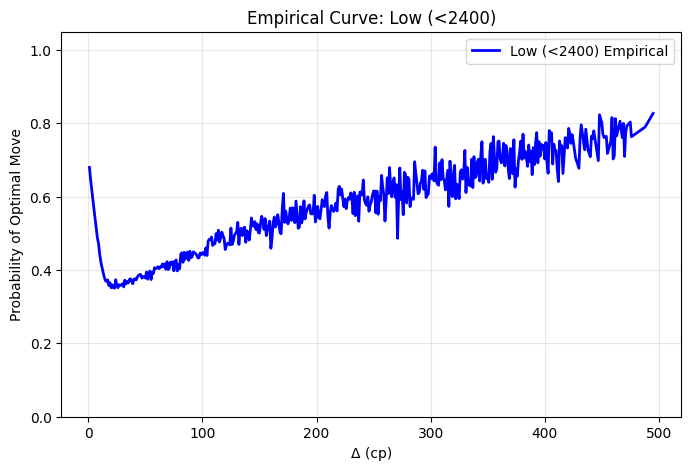

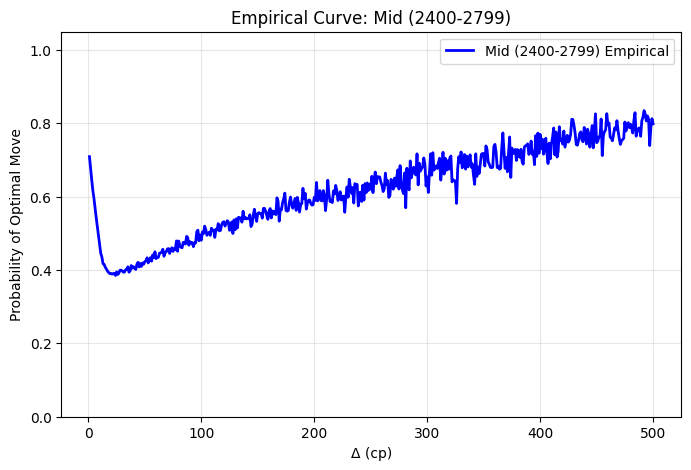

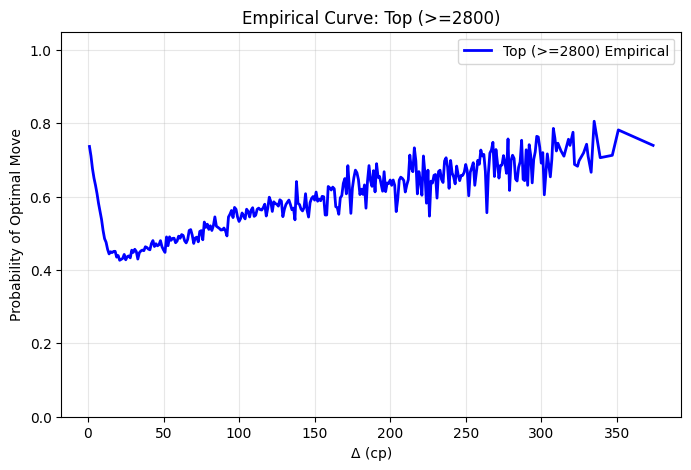

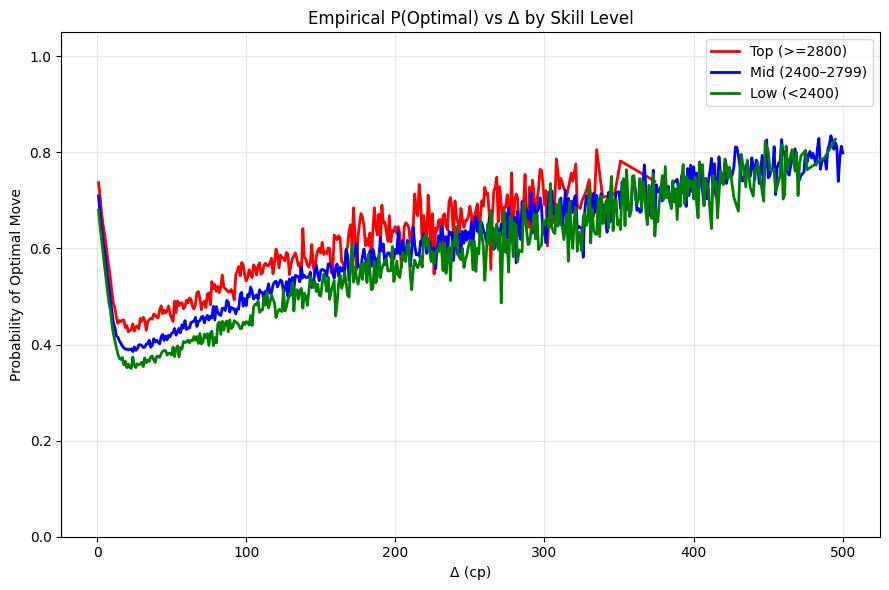

Top 组: A=0.743, 0.73A=0.542, Δ0≈93.0
Mid 组: A=0.713, 0.73A=0.520, Δ0≈117.8
Low 组: A=0.692, 0.73A=0.505, Δ0≈130.0


In [23]:
def empirical_curve(df, group_name, delta_max=1000, show_plot=True):
    group_df = df[(df['ELO_Group']==group_name) & (df['Is_Forced']==0)]
    
    # 只保留 Δ 在 1~delta_max 之间
    group_df = group_df[(group_df['Δ']>0) & (group_df['Δ']<=delta_max)]
    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    #只保留样本量大于100的点去画图
    valid_deltas = counts[counts >= 100].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    # 按 Δ 统计概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal':'P_Optimal'}, inplace=True)
    
    if show_plot:
        plt.figure(figsize=(8,5))
        plt.plot(prob_df['Δ'], prob_df['P_Optimal'], 'b-', lw=2, label=f'{group_name} Empirical')
        plt.xlabel('Δ (cp)')
        plt.ylabel('Probability of Optimal Move')
        plt.title(f'Empirical Curve: {group_name}')
        plt.ylim(0,1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    
    return prob_df

def plot_all_groups(top_curve, mid_curve, low_curve):
    plt.figure(figsize=(9,6))

    plt.plot(top_curve['Δ'], top_curve['P_Optimal'],
             color='red', lw=2, label='Top (>=2800)')
    plt.plot(mid_curve['Δ'], mid_curve['P_Optimal'],
             color='blue', lw=2, label='Mid (2400–2799)')
    plt.plot(low_curve['Δ'], low_curve['P_Optimal'],
             color='green', lw=2, label='Low (<2400)')

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title('Empirical P(Optimal) vs Δ by Skill Level')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_empirical_delta0_left(prob_df, target_prob):
    """prob_df: 包含 ['Δ', 'P_Optimal'] 的 DataFrame（已按 Δ 排序）, target_prob: 目标概率（如 0.73 * A）"""
    x = prob_df['Δ'].values
    y = prob_df['P_Optimal'].values
    
    # 只保留 y 单调上升的区间（避免尾部抖动）
    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    # 如果 target 超出范围，直接返回 None
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    # 插值反解
    delta0 = np.interp(target_prob, y, x)
    return delta0

def get_right_branch(prob_df):
    df = prob_df.sort_values('Δ').reset_index(drop=True)
    
    # 找到最小 P 的位置（下降 → 上升的转折点）
    idx_min = df['P_Optimal'].idxmin()
    
    # 只保留右半段
    return df.loc[idx_min:].reset_index(drop=True)

def get_empirical_delta0_right(prob_df, target_prob):
    right_df = get_right_branch(prob_df)
    
    x = right_df['Δ'].values
    y = right_df['P_Optimal'].values
    
    # 如果 target 不在范围内
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    return np.interp(target_prob, y, x)

def get_empirical_ceiling(df, group_name): 
    # 筛选出该组的大 Delta 数据 (比如 200 到 1000 cp) 
    high_delta_data = df[ (df['ELO_Group'] == group_name) & (df['Δ'] > 200) & (df['Δ'] <= 1000) ] 
    # 直接算 Is_Optimal 的平均值
    A_empirical = high_delta_data['Is_Optimal'].mean() 
    return A_empirical 

# 对所有组循环
groups = df_moves['ELO_Group'].unique()
all_prob_curves = {}
for g in groups:
    all_prob_curves[g] = empirical_curve(df_moves, g, delta_max=500, show_plot=True)
top_curve = all_prob_curves['Top (>=2800)']
mid_curve = all_prob_curves['Mid (2400-2799)']
low_curve = all_prob_curves['Low (<2400)']
plot_all_groups(top_curve, mid_curve, low_curve)


A_top = get_empirical_ceiling(df_moves, 'Top (>=2800)') 
A_mid = get_empirical_ceiling(df_moves, 'Mid (2400-2799)') 
A_low = get_empirical_ceiling(df_moves, 'Low (<2400)') 
A_073_top = A_top*0.73 
A_073_mid = A_mid*0.73 
A_073_low = A_low*0.73 

top_delta0 = get_empirical_delta0_right(top_curve, A_073_top)
mid_delta0 = get_empirical_delta0_right(mid_curve, A_073_mid)
low_delta0 = get_empirical_delta0_right(low_curve, A_073_low)

print(f"Top 组: A={A_top:.3f}, 0.73A={A_073_top:.3f}, Δ0≈{top_delta0:.1f}")
print(f"Mid 组: A={A_mid:.3f}, 0.73A={A_073_mid:.3f}, Δ0≈{mid_delta0:.1f}")
print(f"Low 组: A={A_low:.3f}, 0.73A={A_073_low:.3f}, Δ0≈{low_delta0:.1f}")


A_top = 0.91 的意思是：
在 Top (>=2800) 这一组中，
所有 Δ ∈ (200, 1000] 的走子里，
Is_Optimal == 1 的比例是 0.91

### 1. Engine Evaluation
For a given position at ply $i$, using Stockfish:

- Let $E_1$ be the **best move** evaluation (in centipawns).
- Let $E_2$ be the **second best move** evaluation.
- Define the evaluation gap $\Delta_i$:

$$
\Delta_i = E_1 - E_2
$$

### 2. Probability Model (Boltzmann-like)

We introduce a perception threshold $\Delta_0$ (e.g., $\Delta_0 = 10$ cp for GMs).
The probability of a human finding the optimal move is modeled as:

$$
P(\text{optimal}) = \frac{A}{1 + e^{-\Delta_i / \Delta_0}}
$$

**Limits:**

- If $\Delta_i \gg \Delta_0 \Rightarrow P \to A$ (Move is obvious).
- If $\Delta_i \ll \Delta_0 \Rightarrow P \to \frac{A}{2}$ (Moves are indistinguishable).

### 3. Information Cost (Decision Difficulty)

The difficulty of choosing the move at ply $i$ is measured in bits:

$$
S(\Delta_i) = -\log_2 P
= \log_2 \left( 1 + e^{-\frac{\Delta_i}{\Delta_0}} \right) -\log_2 A
$$



In [24]:
#因为边界选择也会影响，所以这个函数是尝试不同左边界时的各种情况实验
def check_stability(df, group_name):
    print(f"--- 分析组: {group_name} ---")
    print(f"{'Min_Delta':<10} | {'Sample_Size':<12} | {'A_value':<10}")
    print("-" * 36)
    
    # 尝试不同的左边界
    for threshold in [100, 200, 300, 400, 500, 600]:
        subset = df[(df['ELO_Group'] == group_name) & 
                    (df['Δ'] > threshold) & 
                    (df['Δ'] <= 1000)]
        
        count = len(subset)
        if count > 0:
            a_val = subset['Is_Optimal'].mean()
            print(f"{threshold:<10} | {count:<12} | {a_val:.4f}")
        else:
            print(f"{threshold:<10} | 0            | N/A")
    print("\n")

for g in ['Low (<2400)', 'Mid (2400-2799)', 'Top (>=2800)']:
    check_stability(df_moves, g)

--- 分析组: Low (<2400) ---
Min_Delta  | Sample_Size  | A_value   
------------------------------------
100        | 124994       | 0.6005
200        | 63511        | 0.6924
300        | 39963        | 0.7485
400        | 25897        | 0.7846
500        | 15622        | 0.7994
600        | 8224         | 0.8054


--- 分析组: Mid (2400-2799) ---
Min_Delta  | Sample_Size  | A_value   
------------------------------------
100        | 266230       | 0.6287
200        | 137506       | 0.7127
300        | 87499        | 0.7633
400        | 58007        | 0.7970
500        | 35743        | 0.8139
600        | 19302        | 0.8133


--- 分析组: Top (>=2800) ---
Min_Delta  | Sample_Size  | A_value   
------------------------------------
100        | 84522        | 0.6678
200        | 43873        | 0.7431
300        | 28192        | 0.7860
400        | 18949        | 0.8128
500        | 11916        | 0.8221
600        | 6578         | 0.8188




In [25]:
import os
clock_info = pd.read_csv(r'..\..\data\input\clock_info.csv')

In [26]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165..."


In [28]:
from tqdm.auto import tqdm
tqdm.pandas()
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [x]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [v]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

clock_info['white_sec'] = clock_info['white_sec'].progress_apply(ensure_list)
clock_info['black_sec'] = clock_info['black_sec'].progress_apply(ensure_list)
print(clock_info['white_sec'].apply(type).value_counts())
print(clock_info['black_sec'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

  0%|          | 0/1017708 [00:00<?, ?it/s]

white_sec
<class 'list'>    1017708
Name: count, dtype: int64
black_sec
<class 'list'>    1017708
Name: count, dtype: int64


In [29]:
clock_info.head()

,uid,seconds,second_list,white_sec,black_sec
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165..."


In [30]:
clock_info['second_list'] = clock_info['second_list'].progress_apply(ensure_list)
print(clock_info['second_list'].apply(type).value_counts())

  0%|          | 0/1017708 [00:00<?, ?it/s]

second_list
<class 'list'>    1017708
Name: count, dtype: int64


In [31]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group,Game_ID,Is_Forced
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0,2177,Low (<2400),NaN,0
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1,2637,Mid (2400-2799),NaN,0
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1,2177,Low (<2400),NaN,0
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1,2637,Mid (2400-2799),NaN,0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1,2177,Low (<2400),NaN,0


In [32]:
# clock_info合并至df_moves
clock_dict = dict(zip(clock_info['uid'], clock_info['second_list']))
def get_remaining_time(row):
    uid = row['uid']
    move_idx = row['Move_Idx']-1   # Move_Idx比对应的列表里元素index大1
    if uid in clock_dict:
        time_list = clock_dict[uid]
        if move_idx < len(time_list):
            return time_list[move_idx]
    return None
df_moves['Remain_Time'] = df_moves.progress_apply(get_remaining_time, axis=1)

  0%|          | 0/3513215 [00:00<?, ?it/s]

In [33]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group,Game_ID,Is_Forced,Remain_Time
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,0,0,9.0,12.0,0,2177,Low (<2400),NaN,0,180.1
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,0,0,5.0,0.0,1,2637,Mid (2400-2799),NaN,0,178.3
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,0,0,1.0,0.0,1,2177,Low (<2400),NaN,0,179.1
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,0,0,12.0,1.0,1,2637,Mid (2400-2799),NaN,0,178.0
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,0,0,2.0,1.0,1,2177,Low (<2400),NaN,0,179.4


In [34]:
# 根据剩余时间去分组
def time_group(second):
    if second <= 15:
        return 'Extremely Tense (0-15)'
    elif 15< second <= 70:
        return 'Tense (15-70)'
    elif 70< second <=170:
        return 'Middle (70-170)'
    else:
        return 'Rich (>170)'

df_moves['Time_Group'] = df_moves['Remain_Time'].apply(time_group)
df_moves['Time_Group'].value_counts(normalize=True)

Time_Group
Middle (70-170)           0.376401
Tense (15-70)             0.245093
Extremely Tense (0-15)    0.191350
Rich (>170)               0.187156
Name: proportion, dtype: float64

In [35]:
df_moves.head()

,uid,Move_Idx,Player,Color,S,E,E1,E2,P,Judgment_Raw,...,Is_Blunder,Δ,Δ_i,Is_Optimal,ELO,ELO_Group,Game_ID,Is_Forced,Remain_Time,Time_Group
0,1,1,Petra Kejzar,White,0.492,20.0,32.0,23.0,0.711,-,...,0,9.0,12.0,0,2177,Low (<2400),NaN,0,180.1,Rich (>170)
1,1,2,Daniel Barria,Black,0.684,20.0,20.0,25.0,0.622,-,...,0,5.0,0.0,1,2637,Mid (2400-2799),NaN,0,178.3,Rich (>170)
2,1,3,Petra Kejzar,White,0.930,20.0,20.0,19.0,0.525,-,...,0,1.0,0.0,1,2177,Low (<2400),NaN,0,179.1,Rich (>170)
3,1,4,Daniel Barria,Black,0.380,21.0,20.0,32.0,0.769,-,...,0,12.0,1.0,1,2637,Mid (2400-2799),NaN,0,178.0,Rich (>170)
4,1,5,Petra Kejzar,White,0.863,20.0,21.0,19.0,0.550,-,...,0,2.0,1.0,1,2177,Low (<2400),NaN,0,179.4,Rich (>170)


In [36]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'S', 'E', 'E1', 'E2', 'P',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δ', 'Δ_i', 'Is_Optimal',
       'ELO', 'ELO_Group', 'Game_ID', 'Is_Forced', 'Remain_Time',
       'Time_Group'],
      dtype='object')

正在处理: Time=Rich (>170), ELO=Low (<2400), Samples=171636
正在处理: Time=Rich (>170), ELO=Mid (2400-2799), Samples=367025
正在处理: Time=Rich (>170), ELO=Top (>=2800), Samples=118859
正在处理: Time=Middle (70-170), ELO=Low (<2400), Samples=359336
正在处理: Time=Middle (70-170), ELO=Mid (2400-2799), Samples=736357
正在处理: Time=Middle (70-170), ELO=Top (>=2800), Samples=226685
正在处理: Time=Tense (15-70), ELO=Low (<2400), Samples=234423
正在处理: Time=Tense (15-70), ELO=Mid (2400-2799), Samples=483032
正在处理: Time=Tense (15-70), ELO=Top (>=2800), Samples=143610
正在处理: Time=Extremely Tense (0-15), ELO=Low (<2400), Samples=172631
正在处理: Time=Extremely Tense (0-15), ELO=Mid (2400-2799), Samples=373771
正在处理: Time=Extremely Tense (0-15), ELO=Top (>=2800), Samples=125850


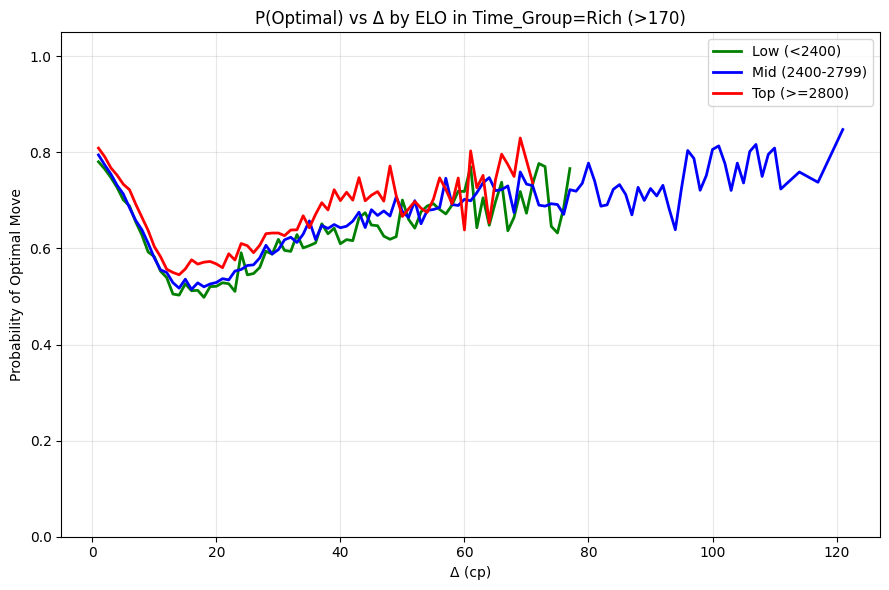

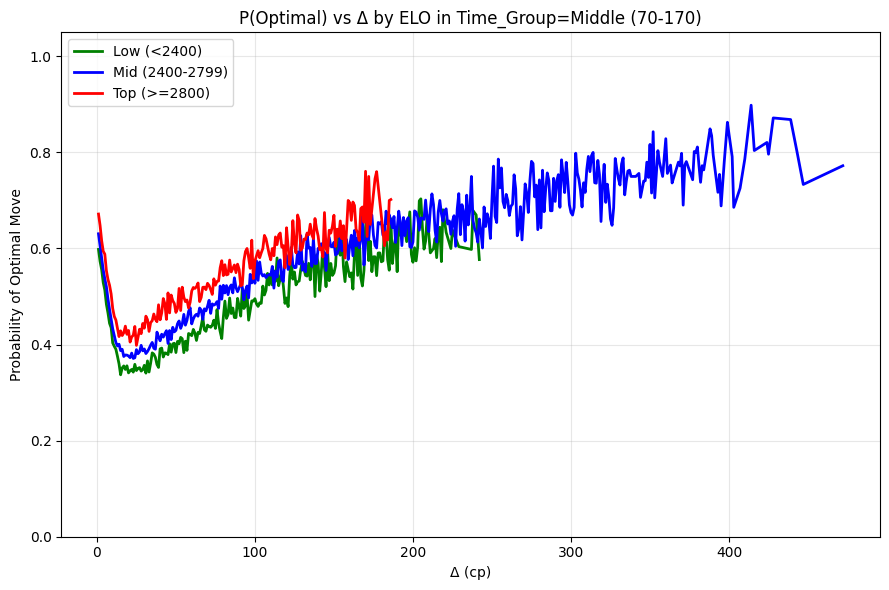

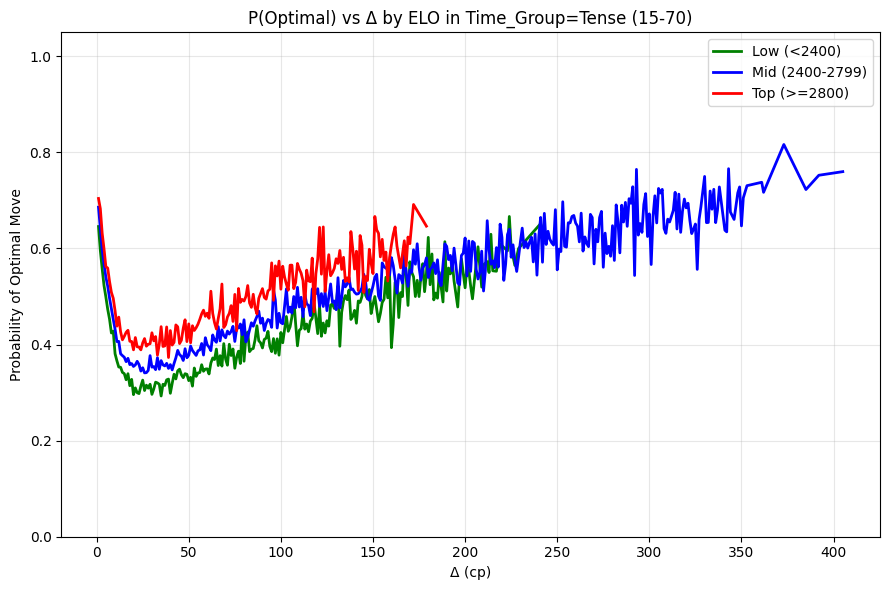

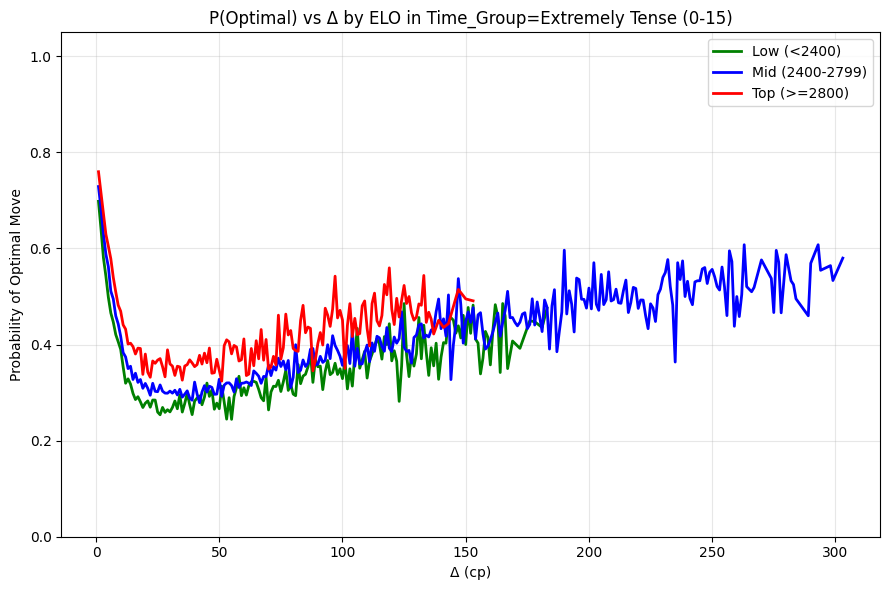

In [40]:
def empirical_curve_v2(df, label, delta_max=1000, show_plot=True):
    # 只过滤非强制着法 和 过滤 Δ 范围
    group_df = df[df['Is_Forced'] == 0].copy()
    group_df = group_df[(group_df['Δ'] > 0) & (group_df['Δ'] <= delta_max)]
    
    if group_df.empty:
        print(f"Warning: No data for {label}")
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    valid_deltas = counts[counts >= 100].index   #50可以调
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    if group_df.empty:
        return pd.DataFrame(columns=['Δ', 'P_Optimal'])

    # 统计概率，prob_df包含每个Δ和对应的最优步概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal': 'P_Optimal'}, inplace=True)
    
    return prob_df

# 按照时间紧张程度看不同elo组的表现情况
all_prob_curves_time = {}
time_groups = df_moves['Time_Group'].unique()
elo_groups = df_moves['ELO_Group'].unique()

for t_group in time_groups:
    all_prob_curves_time[t_group] = {}
    for e_group in elo_groups:
        # 在此处进行精确过滤
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        
        prob_curve = empirical_curve_v2(
            df = sub_df,
            label = f'{e_group} | {t_group}',
            delta_max = 500,
            show_plot = False # 循环中关闭单图，最后一起画总图
        )
        all_prob_curves_time[t_group][e_group] = prob_curve
# 具体画图
for t_group in time_groups:
    plt.figure(figsize=(9,6))
    for e_group, color in zip(elo_groups, ['green', 'blue', 'red']):
        curve = all_prob_curves_time[t_group][e_group]
        if curve is not None and not curve.empty:
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2, color=color, label=e_group)
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'P(Optimal) vs Δ by ELO in Time_Group={t_group}')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

正在处理: Time=Extremely Tense (0-15), ELO=Low (<2400), Samples=172631
正在处理: Time=Middle (70-170), ELO=Low (<2400), Samples=359336
正在处理: Time=Rich (>170), ELO=Low (<2400), Samples=171636
正在处理: Time=Tense (15-70), ELO=Low (<2400), Samples=234423


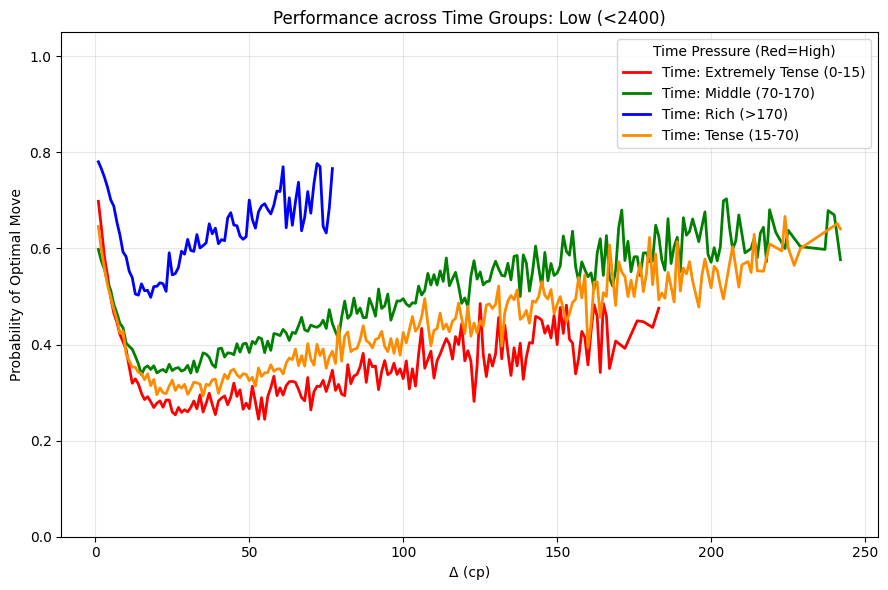

正在处理: Time=Extremely Tense (0-15), ELO=Mid (2400-2799), Samples=373771
正在处理: Time=Middle (70-170), ELO=Mid (2400-2799), Samples=736357
正在处理: Time=Rich (>170), ELO=Mid (2400-2799), Samples=367025
正在处理: Time=Tense (15-70), ELO=Mid (2400-2799), Samples=483032


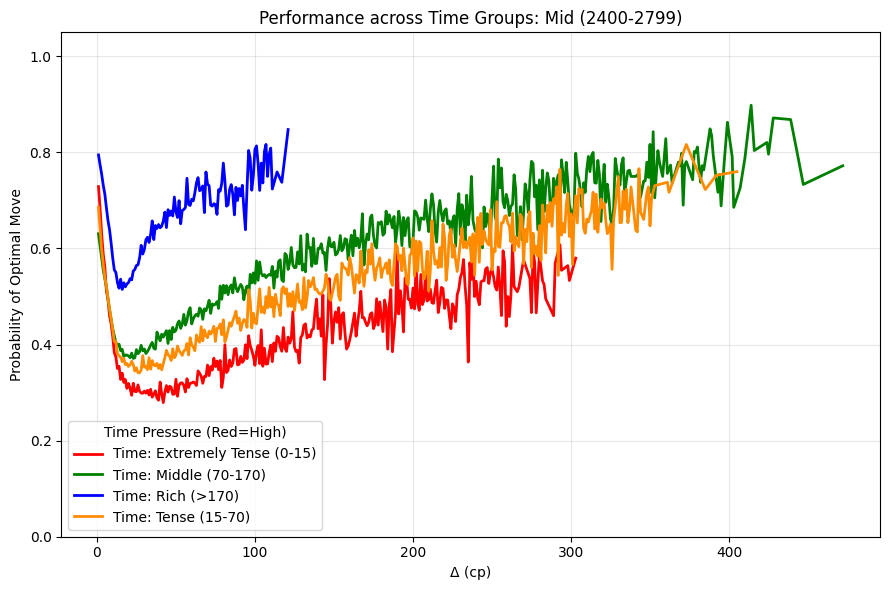

正在处理: Time=Extremely Tense (0-15), ELO=Top (>=2800), Samples=125850
正在处理: Time=Middle (70-170), ELO=Top (>=2800), Samples=226685
正在处理: Time=Rich (>170), ELO=Top (>=2800), Samples=118859
正在处理: Time=Tense (15-70), ELO=Top (>=2800), Samples=143610


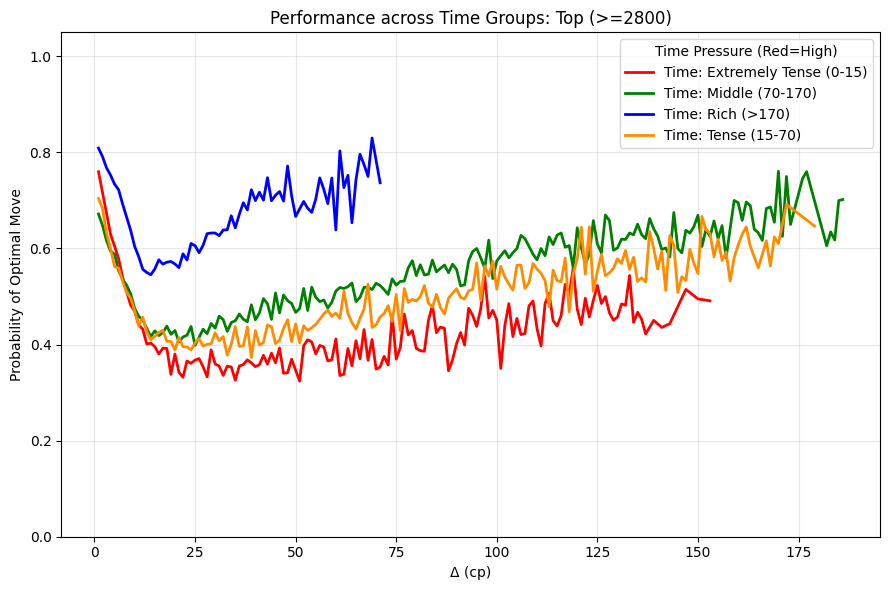

In [39]:
# 看不同elo组在不同时间压力情况下的表现情况
time_color_map = {
    'Extremely Tense (0-15)': 'red', 
    'Tense (15-70)': 'darkorange',
    'Middle (70-170)': 'green',
    'Rich (>170)': 'blue'
}

for e_group in elo_groups:
    plt.figure(figsize=(9, 6))
    sorted_time_groups = sorted(time_groups) 
    
    for t_group in sorted_time_groups:
        # 获取该时间组和ELO组的子集
        sub_df = df_moves[(df_moves['Time_Group'] == t_group) & (df_moves['ELO_Group'] == e_group)]
        print(f"正在处理: Time={t_group}, ELO={e_group}, Samples={len(sub_df)}")
        curve = all_prob_curves_time[t_group].get(e_group)
        
        if curve is not None and not curve.empty:
            # 从字典里取颜色，如果找不到就默认用灰色
            color = time_color_map.get(t_group, 'gray')
            plt.plot(curve['Δ'], curve['P_Optimal'], lw=2,color=color,label=f'Time: {t_group}')
    
    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title(f'Performance across Time Groups: {e_group}')
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend(title="Time Pressure (Red=High)")
    plt.tight_layout()
    plt.show()